<div style="width: 76ch;">
<h3>Ruitewissers</h3>
(<em>Colin Cools, Lander Cortens</em>)



</div>

In [29]:
# Animation of four bar


import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import fsolve
from matplotlib.animation import FuncAnimation
from IPython.display import HTML

%matplotlib widget

In [30]:
# kinematic parameters, in SI units:
r1   = 0.14 #m
r2   = 0.43 #m
r3   = 0.75 #m
r4   = 0.50 #m
r5   = 0.58 #m
r6   = 0.58 #m
r7   = 0.20 #m

rDC  = 0.16 #m
rDF  = 0.20 #m
rED  = 0.14 #m
rIJ  = 0.14 #m

grondA_x = 0.00 #m
grondA_y = 0.00 #m

grondD_x = 0.33 #m
grondD_y = 0.30 #m

grondH_x = 0.83 #m
grondH_y = 0.00 #m

grondI_x = 0.83 #m
grondI_y = 0.30 #m


rAD_x= abs(grondD_x - grondA_x)
rAD_y= abs(grondD_y - grondA_y)

rAH_x= abs(grondH_x - grondA_x)
rAH_y= abs(grondH_y - grondA_y)

rAI_x= abs(grondI_x - grondA_x)
rAI_y= abs(grondI_y - grondA_y)

rDH_x= abs(grondH_x - grondD_x)
rDH_y= abs(grondH_y - grondD_y)

rDI_x = abs(grondD_x - grondI_x)
rDI_y = abs(grondD_y - grondI_y)

omega  = 0.5      # driver frequency [rad/s]
t_begin =  0     # start time of simulation
t_end = 2*np.pi/omega     # end time of simulation
Ts      =  0.10  # target time step of simulation
num_steps = int(np.ceil((t_end - t_begin) / Ts))
t = np.linspace(t_begin, t_end, num_steps + 1)  # time vector for one full turn

# angular position driver:

theta1   = omega * t
dtheta1  = omega * np.ones_like(t)
ddtheta1 = np.zeros_like(t)

# configuration of numerical simulation interval and sampling:



# initial conditions for nonlinear solver ("fsolve") of position closure:
# phi1_init = 1.22 #rad volgens mij is deze bepaald door de motor, dus mag deze weg
theta2_init = 10*np.pi/180  #rad
theta3_init = 120*np.pi/180 #rad
theta4_init = 330*np.pi/180 #rad
theta5_init = 315*np.pi/180 #rad
theta6_init = 0*np.pi/180   #rad
theta7_init = 120*np.pi/180 #rad
# (different choices can lead to different topologies of your mechanism)

In [31]:
# Function to rotate a vector z over an angle theta:
def rotate_vector(z, theta):
    rotation_matrix = np.array([[np.cos(theta), -np.sin(theta)],
                                [np.sin(theta), np.cos(theta)]])
    return np.dot(rotation_matrix, z)

In [32]:
# Define function to compute "gap" in position closure:
def loop_closure_eqs(theta_init, theta1, r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y):
    theta2 = theta_init[0]
    theta3 = theta_init[1]
    theta4 = theta_init[2]
    theta5 = theta_init[3]
    theta6 = theta_init[4]
    theta7 = theta_init[5]
    

    # Loop closure gaps:
    F1 = r1 * np.cos(theta1) + r2 * np.cos(theta2) + rDC * np.cos(theta3) - rAD_x
    F2 = r1 * np.sin(theta1) + r2 * np.sin(theta2) + rDC * np.sin(theta3) - rAD_y

    F3 = -rDF * np.cos(theta3) + r6 * np.cos(theta4) - r7 * np.cos(theta5) - rDH_x
    F4 = -rDF * np.sin(theta3) + r6 * np.sin(theta4) - r7 * np.sin(theta5) + rDH_y

    F5 = rED * np.cos(theta3) + r4 * np.cos(theta6) - rIJ * np.cos(theta7) - rDI_x
    F6 = rED * np.sin(theta3) + r4 * np.sin(theta6) - rIJ * np.sin(theta7) - rDI_y

    return [F1, F2, F3, F4, F5, F6]

In [33]:
# calculating unknown angles at time zero
def angles_at_time_zero(r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y, theta1, dtheta1, ddtheta1, theta2_init, theta3_init,theta4_init,theta5_init,theta6_init,theta7_init, t):
    optim_options = {"full_output":True}  # options for fsolve

  # numerically solving the position closure at all sampling times:
    #for k, time in enumerate(t):
    #for k, time in [0]:
    k=0
    if k ==0:
      # Position Analysis
      x, _, ier, message  = fsolve(lambda x: loop_closure_eqs(x, theta1[k], r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y), [theta2_init, theta3_init,theta4_init,theta5_init,theta6_init,theta7_init], **optim_options)

      if ier != 1:
          print("The fsolve exit flag was not 1, probably no convergence!")
          print(message)

      theta2 = x[0]
      theta3 = x[1]
      theta4 = x[2]
      theta5 = x[3]
      theta6 = x[4]
      theta7 = x[5]

      

    return theta2, theta3, theta4, theta5, theta6, theta7

theta2_0, theta3_0, theta4_0, theta5_0, theta6_0, theta7_0 = angles_at_time_zero(r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y, theta1, dtheta1, ddtheta1, theta2_init, theta3_init,theta4_init,theta5_init,theta6_init,theta7_init, t)
print("theta1:", theta1[0])
print("theta2:", theta2_0)
print("theta3:", theta3_0)
print("theta4:", theta4_0)
print("theta5:", theta5_0)
print("theta6:", theta6_0)
print("theta7:", theta7_0)

theta1: 0.0
theta2: 0.642395299872586
theta3: 2.873514760319175
theta4: 5.76057091081554
theta5: 6.069149301191345
theta6: 1.694461565482411e-10
theta7: 2.8735147598579616


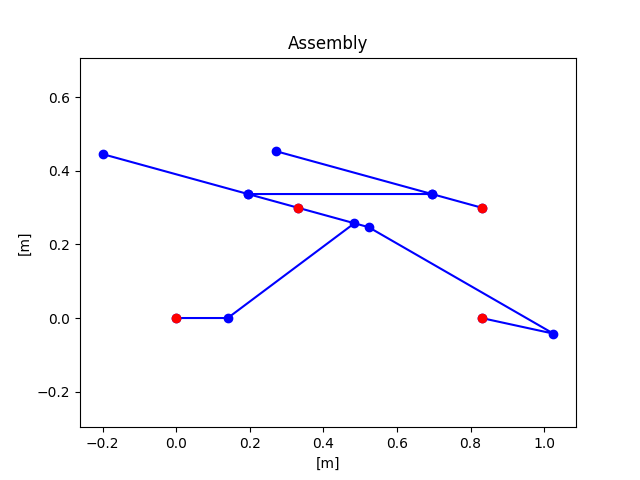

In [34]:
# making plot at time zero
import numpy as np
import matplotlib.pyplot as plt


A = np.array([0, 0])
B = A+ rotate_vector(np.array([r1, 0]), theta1[0])
C = B + rotate_vector(np.array([r2, 0]), theta2_0)
D = A + np.array([rAD_x, rAD_y])
I = A + np.array([rAI_x, rAI_y])
H = A + np.array([rAH_x, rAH_y])
G = H + rotate_vector(np.array([r7, 0]), theta5_0)
F = G - rotate_vector(np.array([r6, 0]), theta4_0)
K = F + rotate_vector(np.array([r3, 0]), theta3_0)
E = F + rotate_vector(np.array([rED + rDF, 0]), theta3_0)
J = I + rotate_vector(np.array([rIJ, 0]), theta7_0)
L = I + rotate_vector(np.array([r5, 0]), theta7_0)



plt.figure()
pad1 = np.array([H, G, F, D, E, J, I])
plt.plot(pad1[:, 0], pad1[:, 1], '-bo')
pad2 = np.array([A, B,C])
plt.plot(pad2[:, 0], pad2[:, 1], '-bo')
pad3 = np.array([E,K])
plt.plot(pad3[:, 0], pad3[:, 1], '-bo')
pad4 = np.array([J,L])
plt.plot(pad4[:, 0], pad4[:, 1], '-bo')

plt.plot(A[0], A[1], 'ro')  # vaste pivot
plt.plot(D[0], D[1], 'ro')
plt.plot(H[0], H[1], 'ro')
plt.plot(I[0], I[1], 'ro')
plt.xlabel('[m]')
plt.ylabel('[m]')
plt.title('Assembly')
plt.axis('equal')
plt.show()




In [35]:
# Function to compute the kinematics
def kinematics(r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y, theta1, dtheta1, ddtheta1, theta2_init, theta3_init,theta4_init,theta5_init,theta6_init,theta7_init, t):
    optim_options = {"full_output":True}  # options for fsolve

  # numerically solving the position closure at all sampling times:
    for k, time in enumerate(t):
      # Position Analysis
      x, _, ier, message  = fsolve(lambda x: loop_closure_eqs(x, theta1[k], r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y), [theta2_init, theta3_init,theta4_init,theta5_init,theta6_init,theta7_init], **optim_options)

      if ier != 1:
          print("The fsolve exit flag was not 1, probably no convergence!")
          print(message)

      theta2[k] = x[0]
      theta3[k] = x[1]
      theta4[k] = x[2]
      theta5[k] = x[3]
      theta6[k] = x[4]
      theta7[k] = x[5]

      # velocity closure:
      A = np.array([
        [-r2*np.sin(theta2[k]), -rDC*np.sin(theta3[k]), 0, 0, 0, 0],
        [ r2*np.cos(theta2[k]),  rDC*np.cos(theta3[k]), 0, 0, 0, 0],
        [0,  rDF*np.sin(theta3[k]), -r6*np.sin(theta4[k]),  r7*np.sin(theta5[k]), 0, 0],
        [0, -rDF*np.cos(theta3[k]),  r6*np.cos(theta4[k]), -r7*np.cos(theta5[k]), 0, 0],
        [0, -rED*np.sin(theta3[k]), 0, 0, -r4*np.sin(theta6[k]),  rIJ*np.sin(theta7[k])],
        [0,  rED*np.cos(theta3[k]), 0, 0,  r4*np.cos(theta6[k]), -rIJ*np.cos(theta7[k])]
      ])

      B = np.array([
        r1*np.sin(theta1[k])*dtheta1[k],
        -r1*np.cos(theta1[k])*dtheta1[k],
        0,
        0,
        0,
        0
      ])

      x = np.linalg.solve(A, B)
      cond[k]  = np.linalg.cond(A)

      dtheta2[k] = x[0]
      dtheta3[k] = x[1]
      dtheta4[k] = x[2]
      dtheta5[k] = x[3]
      dtheta6[k] = x[4]
      dtheta7[k] = x[5]

      A = np.array([
        [-r2*np.sin(theta2[k]), -rDC*np.sin(theta3[k]), 0, 0, 0, 0],
        [ r2*np.cos(theta2[k]),  rDC*np.cos(theta3[k]), 0, 0, 0, 0],
        [0,  rDF*np.sin(theta3[k]), -r6*np.sin(theta4[k]),  r7*np.sin(theta5[k]), 0, 0],
        [0, -rDF*np.cos(theta3[k]),  r6*np.cos(theta4[k]), -r7*np.cos(theta5[k]), 0, 0],
        [0, -rED*np.sin(theta3[k]), 0, 0, -r4*np.sin(theta6[k]),  rIJ*np.sin(theta7[k])],
        [0,  rED*np.cos(theta3[k]), 0, 0,  r4*np.cos(theta6[k]), -rIJ*np.cos(theta7[k])]
      ])

      B = np.array([
        r1*np.cos(theta1[k])*dtheta1[k]**2 + r1*np.sin(theta1[k])*ddtheta1[k]
        + r2*np.cos(theta2[k])*dtheta2[k]**2 + rDC*np.cos(theta3[k])*dtheta3[k]**2,

        r1*np.sin(theta1[k])*dtheta1[k]**2 - r1*np.cos(theta1[k])*ddtheta1[k]
        + r2*np.sin(theta2[k])*dtheta2[k]**2 + rDC*np.sin(theta3[k])*dtheta3[k]**2,

        -rDF*np.cos(theta3[k])*dtheta3[k]**2 + r6*np.cos(theta4[k])*dtheta4[k]**2 - r7*np.cos(theta5[k])*dtheta5[k]**2,

        -rDF*np.sin(theta3[k])*dtheta3[k]**2 + r6*np.sin(theta4[k])*dtheta4[k]**2 - r7*np.sin(theta5[k])*dtheta5[k]**2,

        rED*np.cos(theta3[k])*dtheta3[k]**2 + r4*np.cos(theta6[k])*dtheta6[k]**2 - rIJ*np.cos(theta7[k])*dtheta7[k]**2,

        rED*np.sin(theta3[k])*dtheta3[k]**2 + r4*np.sin(theta6[k])*dtheta6[k]**2 - rIJ*np.sin(theta7[k])*dtheta7[k]**2
      ])

      x = np.linalg.solve(A, B)

      ddtheta2[k] = x[0]
      ddtheta3[k] = x[1]
      ddtheta4[k] = x[2]
      ddtheta5[k] = x[3]
      ddtheta6[k] = x[4]
      ddtheta7[k] = x[5] 

      theta2_init = theta2[k] + (t[1] - t[0])*dtheta2[k]
      theta3_init = theta3[k] + (t[1] - t[0])*dtheta3[k]
      theta4_init = theta4[k] + (t[1] - t[0])*dtheta4[k]
      theta5_init = theta5[k] + (t[1] - t[0])*dtheta5[k]
      theta6_init = theta6[k] + (t[1] - t[0])*dtheta6[k]
      theta7_init = theta7[k] + (t[1] - t[0])*dtheta7[k]

    return theta2, theta3, theta4, theta5, theta6, theta7, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7, cond

In [36]:
theta2   = np.zeros_like(t)
theta3   = np.zeros_like(t)
theta4   = np.zeros_like(t)
theta5   = np.zeros_like(t)
theta6   = np.zeros_like(t)
theta7   = np.zeros_like(t)

dtheta2   = np.zeros_like(t)
dtheta3   = np.zeros_like(t)
dtheta4   = np.zeros_like(t)
dtheta5   = np.zeros_like(t)
dtheta6   = np.zeros_like(t)
dtheta7   = np.zeros_like(t)

ddtheta2   = np.zeros_like(t)
ddtheta3   = np.zeros_like(t)
ddtheta4   = np.zeros_like(t)
ddtheta5   = np.zeros_like(t)
ddtheta6   = np.zeros_like(t)
ddtheta7   = np.zeros_like(t)

cond   = np.zeros_like(t) # condition number of matrix A

t_size = len(t)              # number of iterations
sim_fraction = 2             # fraction of simulated frames in animation
frames = int(t_size / sim_fraction)# number of animated iterations
delta = int(np.floor(t_size/frames))    # time between frames
index_vec = np.arange(0, t_size, delta) # index of animated frames  

theta2, theta3, theta4, theta5, theta6, theta7, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7, cond = kinematics(r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ, rAD_x, rAD_y, rDI_x, rDI_y, theta1, dtheta1, ddtheta1, theta2_init, theta3_init,theta4_init,theta5_init,theta6_init,theta7_init, t)

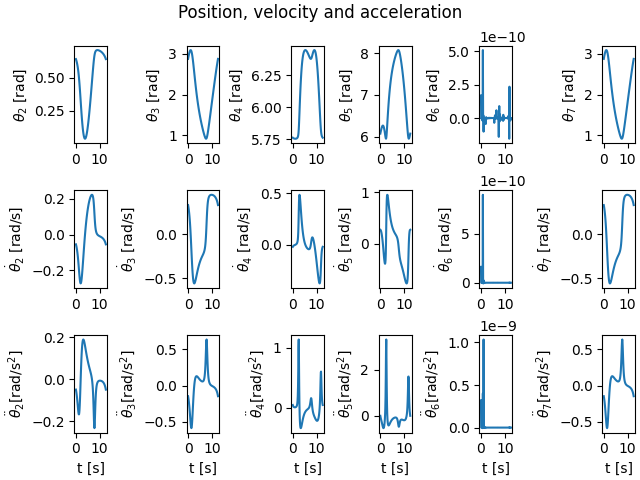

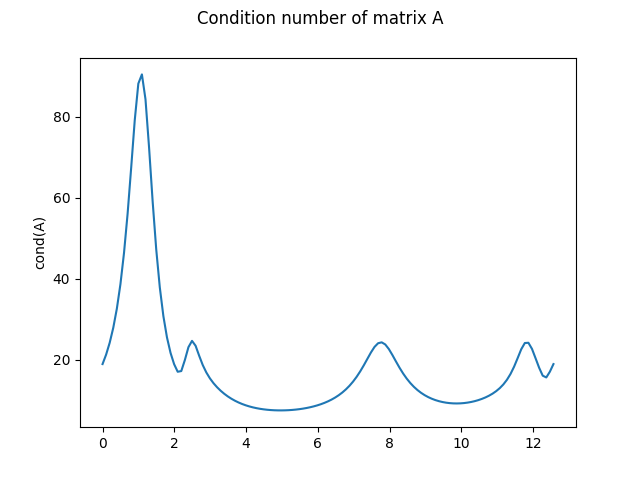

In [37]:
# plot position, velocity and acceleration profiles:

fig1, ax1 = plt.subplots(nrows=3,ncols=6,constrained_layout=True)
fig1.suptitle("Position, velocity and acceleration")

ax1[0,0].plot(t, theta2)
ax1[0,0].set_ylabel(r'$\theta_2$ [rad]')

ax1[0,1].plot(t, theta3)
ax1[0,1].set_ylabel(r'$\theta_3$ [rad]')

ax1[0,2].plot(t, theta4)
ax1[0,2].set_ylabel(r'$\theta_4$ [rad]')

ax1[0,3].plot(t, theta5)
ax1[0,3].set_ylabel(r'$\theta_5$ [rad]')

ax1[0,4].plot(t, theta6)
ax1[0,4].set_ylabel(r'$\theta_6$ [rad]')

ax1[0,5].plot(t, theta7)
ax1[0,5].set_ylabel(r'$\theta_7$ [rad]')

ax1[1,0].plot(t, dtheta2)
ax1[1,0].set_ylabel(r'$\dot{\theta}_2$ [rad/s]')

ax1[1,1].plot(t, dtheta3)
ax1[1,1].set_ylabel(r'$\dot{\theta}_3$ [rad/s]')

ax1[1,2].plot(t, dtheta4)
ax1[1,2].set_ylabel(r'$\dot{\theta}_4$ [rad/s]')

ax1[1,3].plot(t, dtheta5)
ax1[1,3].set_ylabel(r'$\dot{\theta}_5$ [rad/s]')

ax1[1,4].plot(t, dtheta6)
ax1[1,4].set_ylabel(r'$\dot{\theta}_6$ [rad/s]')

ax1[1,5].plot(t, dtheta7)
ax1[1,5].set_ylabel(r'$\dot{\theta}_7$ [rad/s]')

ax1[2,0].plot(t, ddtheta2)
ax1[2,0].set_ylabel(r'$\ddot{\theta}_2 [\text{rad/s}^2]$')
ax1[2,0].set_xlabel('t [s]')

ax1[2,1].plot(t, ddtheta3)
ax1[2,1].set_ylabel(r'$\ddot{\theta}_3 [\text{rad/s}^2]$')
ax1[2,1].set_xlabel('t [s]')

ax1[2,2].plot(t, ddtheta4)
ax1[2,2].set_ylabel(r'$\ddot{\theta}_4 [\text{rad/s}^2]$')
ax1[2,2].set_xlabel('t [s]')

ax1[2,3].plot(t, ddtheta5)
ax1[2,3].set_ylabel(r'$\ddot{\theta}_5 [\text{rad/s}^2]$')
ax1[2,3].set_xlabel('t [s]')

ax1[2,4].plot(t, ddtheta6)
ax1[2,4].set_ylabel(r'$\ddot{\theta}_6 [\text{rad/s}^2]$')
ax1[2,4].set_xlabel('t [s]')

ax1[2,5].plot(t, ddtheta7)
ax1[2,5].set_ylabel(r'$\ddot{\theta}_7 [\text{rad/s}^2]$')
ax1[2,5].set_xlabel('t [s]')

plt.show()

# plot of condition number:
figc, axc = plt.subplots()
figc.suptitle("Condition number of matrix A")

axc.plot(t, cond)
axc.set_ylabel("cond(A)")
plt.show()

In [38]:
# Animation of mechanism motion
plt.ioff()               # don't show figure until drawn explicitly:
fig2, ax = plt.subplots() # Initialize the figure

# compute width and height of drawing canvas:
x_left   = -1.25 * max(r1, r3 -rAD_x - rDF)
y_bottom = -1.25 * max(r1, r7)
x_right  = rAH_x + 1.25 * max(r7, r5)
y_top    = rAD_y + 1.25 * max(r5, r3 -rDF)

# function to update the animation every "delta" steps:
def update(frame):
    global fig2, ax, x_left, x_right, y_bottom, y_top, P, S, index_vec
    ax.cla()         # Clear the current axes
    ax.axis('equal') # Ensures 1 unit on x == 1 unit on y
    ax.set_xlabel('[m]')
    ax.set_ylabel('[m]')
    ax.set_xlim([x_left, x_right])
    ax.set_ylim([y_bottom, y_top])
    time_now = t[index_vec[frame]]
    ax.set_title(f'Time {time_now: .2f}')
    #ax.set_title(f'Frame {frame}')

    # Calculate Cartesian coordinates of mechanism joints:
    A = np.array([0, 0])
    B = A+ rotate_vector(np.array([r1, 0]), theta1[index_vec[frame]])
    C = B + rotate_vector(np.array([r2, 0]), theta2[index_vec[frame]])
    D = A + np.array([rAD_x, rAD_y])
    I = A + np.array([rAI_x, rAI_y])
    H = A + np.array([rAH_x, rAH_y])
    G = H + rotate_vector(np.array([r7, 0]), theta5[index_vec[frame]])
    F = G - rotate_vector(np.array([r6, 0]), theta4[index_vec[frame]])
    K = F + rotate_vector(np.array([r3, 0]), theta3[index_vec[frame]])
    E = F + rotate_vector(np.array([rED + rDF, 0]), theta3[index_vec[frame]])
    J = I + rotate_vector(np.array([rIJ, 0]), theta7[index_vec[frame]])
    L = I + rotate_vector(np.array([r5, 0]), theta7[index_vec[frame]])

    pad1 = np.array([H, G, F, C, D, E, J, I])
    ax.plot(pad1[:, 0], pad1[:, 1], '-bo')
    pad2 = np.array([A, B,C])
    ax.plot(pad2[:, 0], pad2[:, 1], '-bo')
    pad3 = np.array([E,K])
    ax.plot(pad3[:, 0], pad3[:, 1], '-bo')
    pad4 = np.array([J,L])
    ax.plot(pad4[:, 0], pad4[:, 1], '-bo')

    ax.plot(A[0], A[1], 'ro')  # vaste pivot
    ax.plot(D[0], D[1], 'ro')
    ax.plot(H[0], H[1], 'ro')
    ax.plot(I[0], I[1], 'ro')
    return(ax)

# animate the mechanism:
ani = FuncAnimation(fig2, update, frames=len(index_vec), interval=50, repeat='false')
# display mechanism animation:
ani_html = ani.to_jshtml(default_mode='once')
HTML(ani_html)

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.
Ignoring fixed x

In [ ]:
# dynamic parameters, defined in a local frame on each of the bars:
X1 = r1 / 2    # X coordinates of cog (centre of gravity)
X2 = r2 / 2
X3 = r3 / 2 - rDF   # cog of link 3 measured from ground pivot D
X4 = r4 / 2         # cog of link 4 measured from joint E
X5 = r5 / 2         # cog of link 5 measured from ground pivot I
X6 = r6 / 2         # cog of link 6 measured from joint F
X7 = r7 / 2         # cog of link 7 measured from ground pivot H

Y1 = 0         # Y coordinates of cog
Y2 = 0
Y3 = 0
Y4 = 0
Y5 = 0
Y6 = 0
Y7 = 0

m1 = r1 * 15.4 # mass of round steel bar of 5cm diameter
m2 = r2 * 15.4
m3 = r3 * 15.4
m4 = r4 * 15.4
m5 = r5 * 15.4
m6 = r6 * 15.4
m7 = r7 * 15.4

# moments of inertia at center of mass (formula of a thin rod):
J1 = m1 * r1 ** 2 / 12
J2 = m2 * r2 ** 2 / 12
J3 = m3 * r3 ** 2 / 12
J4 = m4 * r4 ** 2 / 12
J5 = m5 * r5 ** 2 / 12
J6 = m6 * r6 ** 2 / 12
J7 = m7 * r7 ** 2 / 12


In [ ]:
# formulas for inverse dynamics:
def dynamics_ruitenwissers(theta1, theta2, theta3, theta4, theta5, theta6, theta7,
                           dtheta1, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7,
                           ddtheta1, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7,
                           r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ,
                           m1, m2, m3, m4, m5, m6, m7,
                           X1, X2, X3, X4, X5, X6, X7,
                           Y1, Y2, Y3, Y4, Y5, Y6, Y7,
                           J1, J2, J3, J4, J5, J6, J7, t):
    # link numbering follows the sketch:
    # link 4 uses theta6, link 5 uses theta7, link 6 uses theta4 and link 7 uses theta5

    # Define vectors from the center of gravity of each bar to the joints on that bar
    cog1_A_x = -X1 * np.cos(theta1) - Y1 * np.cos(theta1 + np.pi / 2)
    cog1_A_y = -X1 * np.sin(theta1) - Y1 * np.sin(theta1 + np.pi / 2)
    cog1_B_x = (r1 - X1) * np.cos(theta1) - Y1 * np.cos(theta1 + np.pi / 2)
    cog1_B_y = (r1 - X1) * np.sin(theta1) - Y1 * np.sin(theta1 + np.pi / 2)

    cog2_B_x = -X2 * np.cos(theta2) - Y2 * np.cos(theta2 + np.pi / 2)
    cog2_B_y = -X2 * np.sin(theta2) - Y2 * np.sin(theta2 + np.pi / 2)
    cog2_C_x = (r2 - X2) * np.cos(theta2) - Y2 * np.cos(theta2 + np.pi / 2)
    cog2_C_y = (r2 - X2) * np.sin(theta2) - Y2 * np.sin(theta2 + np.pi / 2)

    cog3_C_x = (-rDC - X3) * np.cos(theta3) - Y3 * np.cos(theta3 + np.pi / 2)
    cog3_C_y = (-rDC - X3) * np.sin(theta3) - Y3 * np.sin(theta3 + np.pi / 2)
    cog3_D_x = -X3 * np.cos(theta3) - Y3 * np.cos(theta3 + np.pi / 2)
    cog3_D_y = -X3 * np.sin(theta3) - Y3 * np.sin(theta3 + np.pi / 2)
    cog3_E_x = (rED - X3) * np.cos(theta3) - Y3 * np.cos(theta3 + np.pi / 2)
    cog3_E_y = (rED - X3) * np.sin(theta3) - Y3 * np.sin(theta3 + np.pi / 2)
    cog3_F_x = (-rDF - X3) * np.cos(theta3) - Y3 * np.cos(theta3 + np.pi / 2)
    cog3_F_y = (-rDF - X3) * np.sin(theta3) - Y3 * np.sin(theta3 + np.pi / 2)

    cog4_E_x = -X4 * np.cos(theta6) - Y4 * np.cos(theta6 + np.pi / 2)
    cog4_E_y = -X4 * np.sin(theta6) - Y4 * np.sin(theta6 + np.pi / 2)
    cog4_J_x = (r4 - X4) * np.cos(theta6) - Y4 * np.cos(theta6 + np.pi / 2)
    cog4_J_y = (r4 - X4) * np.sin(theta6) - Y4 * np.sin(theta6 + np.pi / 2)

    cog5_I_x = -X5 * np.cos(theta7) - Y5 * np.cos(theta7 + np.pi / 2)
    cog5_I_y = -X5 * np.sin(theta7) - Y5 * np.sin(theta7 + np.pi / 2)
    cog5_J_x = (rIJ - X5) * np.cos(theta7) - Y5 * np.cos(theta7 + np.pi / 2)
    cog5_J_y = (rIJ - X5) * np.sin(theta7) - Y5 * np.sin(theta7 + np.pi / 2)

    cog6_F_x = -X6 * np.cos(theta4) - Y6 * np.cos(theta4 + np.pi / 2)
    cog6_F_y = -X6 * np.sin(theta4) - Y6 * np.sin(theta4 + np.pi / 2)
    cog6_G_x = (r6 - X6) * np.cos(theta4) - Y6 * np.cos(theta4 + np.pi / 2)
    cog6_G_y = (r6 - X6) * np.sin(theta4) - Y6 * np.sin(theta4 + np.pi / 2)

    cog7_H_x = -X7 * np.cos(theta5) - Y7 * np.cos(theta5 + np.pi / 2)
    cog7_H_y = -X7 * np.sin(theta5) - Y7 * np.sin(theta5 + np.pi / 2)
    cog7_G_x = (r7 - X7) * np.cos(theta5) - Y7 * np.cos(theta5 + np.pi / 2)
    cog7_G_y = (r7 - X7) * np.sin(theta5) - Y7 * np.sin(theta5 + np.pi / 2)

    # Define 3D vectors omega (dtheta) and alpha (ddtheta)
    omega1 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta1))
    omega2 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta2))
    omega3 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta3))
    omega4 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta6))
    omega5 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta7))
    omega6 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta4))
    omega7 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), dtheta5))

    alpha1 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta1))
    alpha2 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta2))
    alpha3 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta3))
    alpha4 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta6))
    alpha5 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta7))
    alpha6 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta4))
    alpha7 = np.column_stack((np.zeros_like(theta1), np.zeros_like(theta1), ddtheta5))

    # Define 3D model vectors
    A_cog1_vec = np.column_stack((-cog1_A_x, -cog1_A_y, np.zeros_like(theta1)))
    B_cog2_vec = np.column_stack((-cog2_B_x, -cog2_B_y, np.zeros_like(theta1)))
    D_cog3_vec = np.column_stack((-cog3_D_x, -cog3_D_y, np.zeros_like(theta1)))
    E_cog4_vec = np.column_stack((-cog4_E_x, -cog4_E_y, np.zeros_like(theta1)))
    I_cog5_vec = np.column_stack((-cog5_I_x, -cog5_I_y, np.zeros_like(theta1)))
    F_cog6_vec = np.column_stack((-cog6_F_x, -cog6_F_y, np.zeros_like(theta1)))
    H_cog7_vec = np.column_stack((-cog7_H_x, -cog7_H_y, np.zeros_like(theta1)))

    AB_vec = np.column_stack((r1 * np.cos(theta1), r1 * np.sin(theta1), np.zeros_like(theta1)))
    BC_vec = np.column_stack((r2 * np.cos(theta2), r2 * np.sin(theta2), np.zeros_like(theta1)))
    DE_vec = np.column_stack((rED * np.cos(theta3), rED * np.sin(theta3), np.zeros_like(theta1)))
    DF_vec = np.column_stack((-rDF * np.cos(theta3), -rDF * np.sin(theta3), np.zeros_like(theta1)))
    EJ_vec = np.column_stack((r4 * np.cos(theta6), r4 * np.sin(theta6), np.zeros_like(theta1)))
    FG_vec = np.column_stack((r6 * np.cos(theta4), r6 * np.sin(theta4), np.zeros_like(theta1)))

    # Define acceleration vectors
    acc_1 = np.cross(omega1, np.cross(omega1, A_cog1_vec)) + np.cross(alpha1, A_cog1_vec)
    acc_B = np.cross(omega1, np.cross(omega1, AB_vec)) + np.cross(alpha1, AB_vec)
    acc_2 = acc_B + np.cross(omega2, np.cross(omega2, B_cog2_vec)) + np.cross(alpha2, B_cog2_vec)
    acc_3 = np.cross(omega3, np.cross(omega3, D_cog3_vec)) + np.cross(alpha3, D_cog3_vec)
    acc_E = np.cross(omega3, np.cross(omega3, DE_vec)) + np.cross(alpha3, DE_vec)
    acc_F = np.cross(omega3, np.cross(omega3, DF_vec)) + np.cross(alpha3, DF_vec)
    acc_4 = acc_E + np.cross(omega4, np.cross(omega4, E_cog4_vec)) + np.cross(alpha4, E_cog4_vec)
    acc_5 = np.cross(omega5, np.cross(omega5, I_cog5_vec)) + np.cross(alpha5, I_cog5_vec)
    acc_6 = acc_F + np.cross(omega6, np.cross(omega6, F_cog6_vec)) + np.cross(alpha6, F_cog6_vec)
    acc_7 = np.cross(omega7, np.cross(omega7, H_cog7_vec)) + np.cross(alpha7, H_cog7_vec)

    acc_1x = acc_1[:, 0]
    acc_1y = acc_1[:, 1]
    acc_2x = acc_2[:, 0]
    acc_2y = acc_2[:, 1]
    acc_3x = acc_3[:, 0]
    acc_3y = acc_3[:, 1]
    acc_4x = acc_4[:, 0]
    acc_4y = acc_4[:, 1]
    acc_5x = acc_5[:, 0]
    acc_5y = acc_5[:, 1]
    acc_6x = acc_6[:, 0]
    acc_6y = acc_6[:, 1]
    acc_7x = acc_7[:, 0]
    acc_7y = acc_7[:, 1]

    # Calculate dynamics for each time step
    t_size = len(t)
    for k in range(t_size):
        A = np.array([
            [1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, -1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, -1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, -1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, -1, 0, 1, 0, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 1, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 1, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 0, 0, 0, 0, 1, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 1, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, -1, 0, 1, 0],
            [-cog1_A_y[k], cog1_A_x[k], -cog1_B_y[k], cog1_B_x[k], 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1],
            [0, 0, cog2_B_y[k], -cog2_B_x[k], -cog2_C_y[k], cog2_C_x[k], 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, cog3_C_y[k], -cog3_C_x[k], -cog3_D_y[k], cog3_D_x[k], -cog3_E_y[k], cog3_E_x[k], -cog3_F_y[k], cog3_F_x[k], 0, 0, 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, cog4_E_y[k], -cog4_E_x[k], 0, 0, -cog4_J_y[k], cog4_J_x[k], 0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, cog5_J_y[k], -cog5_J_x[k], -cog5_I_y[k], cog5_I_x[k], 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, cog6_F_y[k], -cog6_F_x[k], 0, 0, 0, 0, -cog6_G_y[k], cog6_G_x[k], 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, cog7_G_y[k], -cog7_G_x[k], -cog7_H_y[k], cog7_H_x[k], 0],
        ])

        B = np.array([
            m1 * acc_1x[k],
            m1 * acc_1y[k],
            m2 * acc_2x[k],
            m2 * acc_2y[k],
            m3 * acc_3x[k],
            m3 * acc_3y[k],
            m4 * acc_4x[k],
            m4 * acc_4y[k],
            m5 * acc_5x[k],
            m5 * acc_5y[k],
            m6 * acc_6x[k],
            m6 * acc_6y[k],
            m7 * acc_7x[k],
            m7 * acc_7y[k],
            J1 * ddtheta1[k],
            J2 * ddtheta2[k],
            J3 * ddtheta3[k],
            J4 * ddtheta6[k],
            J5 * ddtheta7[k],
            J6 * ddtheta4[k],
            J7 * ddtheta5[k],
        ])

        x = np.linalg.lstsq(A, B, rcond=None)[0]

        # Save results
        F_A_x[k] = x[0]
        F_A_y[k] = x[1]
        F_B_x[k] = x[2]
        F_B_y[k] = x[3]
        F_C_x[k] = x[4]
        F_C_y[k] = x[5]
        F_D_x[k] = x[6]
        F_D_y[k] = x[7]
        F_E_x[k] = x[8]
        F_E_y[k] = x[9]
        F_F_x[k] = x[10]
        F_F_y[k] = x[11]
        F_J_x[k] = x[12]
        F_J_y[k] = x[13]
        F_I_x[k] = x[14]
        F_I_y[k] = x[15]
        F_G_x[k] = x[16]
        F_G_y[k] = x[17]
        F_H_x[k] = x[18]
        F_H_y[k] = x[19]
        M_A[k] = x[20]

    return (F_A_x, F_B_x, F_C_x, F_D_x, F_E_x, F_F_x, F_G_x, F_H_x, F_I_x, F_J_x,
            F_A_y, F_B_y, F_C_y, F_D_y, F_E_y, F_F_y, F_G_y, F_H_y, F_I_y, F_J_y, M_A)

# compute inverse dynamics:
# Allocate matrices for force (F) and moment (M)
F_A_x = np.zeros_like(t)
F_A_y = np.zeros_like(t)
F_B_x = np.zeros_like(t)
F_B_y = np.zeros_like(t)
F_C_x = np.zeros_like(t)
F_C_y = np.zeros_like(t)
F_D_x = np.zeros_like(t)
F_D_y = np.zeros_like(t)
F_E_x = np.zeros_like(t)
F_E_y = np.zeros_like(t)
F_F_x = np.zeros_like(t)
F_F_y = np.zeros_like(t)
F_G_x = np.zeros_like(t)
F_G_y = np.zeros_like(t)
F_H_x = np.zeros_like(t)
F_H_y = np.zeros_like(t)
F_I_x = np.zeros_like(t)
F_I_y = np.zeros_like(t)
F_J_x = np.zeros_like(t)
F_J_y = np.zeros_like(t)
M_A   = np.zeros_like(t)

(
    F_A_x, F_B_x, F_C_x, F_D_x, F_E_x, F_F_x, F_G_x, F_H_x, F_I_x, F_J_x,
    F_A_y, F_B_y, F_C_y, F_D_y, F_E_y, F_F_y, F_G_y, F_H_y, F_I_y, F_J_y, M_A
) = dynamics_ruitenwissers(
    theta1, theta2, theta3, theta4, theta5, theta6, theta7,
    dtheta1, dtheta2, dtheta3, dtheta4, dtheta5, dtheta6, dtheta7,
    ddtheta1, ddtheta2, ddtheta3, ddtheta4, ddtheta5, ddtheta6, ddtheta7,
    r1, r2, r3, r4, r5, r6, r7, rDC, rDF, rED, rIJ,
    m1, m2, m3, m4, m5, m6, m7,
    X1, X2, X3, X4, X5, X6, X7,
    Y1, Y2, Y3, Y4, Y5, Y6, Y7,
    J1, J2, J3, J4, J5, J6, J7, t
)


In [ ]:
# plot forces and moments:
fig3, ax3 = plt.subplots(nrows=5, ncols=2, constrained_layout=True, figsize=(12, 10))
fig3.suptitle("Forces")

force_pairs = [
    ("A", F_A_x, F_A_y),
    ("B", F_B_x, F_B_y),
    ("C", F_C_x, F_C_y),
    ("D", F_D_x, F_D_y),
    ("E", F_E_x, F_E_y),
    ("F", F_F_x, F_F_y),
    ("G", F_G_x, F_G_y),
    ("H", F_H_x, F_H_y),
    ("I", F_I_x, F_I_y),
    ("J", F_J_x, F_J_y),
]

for axis, (label, force_x, force_y) in zip(ax3.flat, force_pairs):
    axis.plot(t, force_x, label="x")
    axis.plot(t, force_y, label="y")
    axis.set_ylabel(rf'$F_{{{label}x}}, F_{{{label}y}}$ [N]')
    axis.set_xlabel('t [s]')

ax3[0, 0].legend()
plt.show()

fig4, ax4 = plt.subplots(constrained_layout=True, figsize=(5, 2.5))
fig4.suptitle("Input moment $M_A$")
ax4.plot(t, M_A)
ax4.set_ylabel(r'$M_A$ [Nm]')
ax4.set_xlabel('t [s]')
plt.show()
